# Homework: Artificial Neural Networks

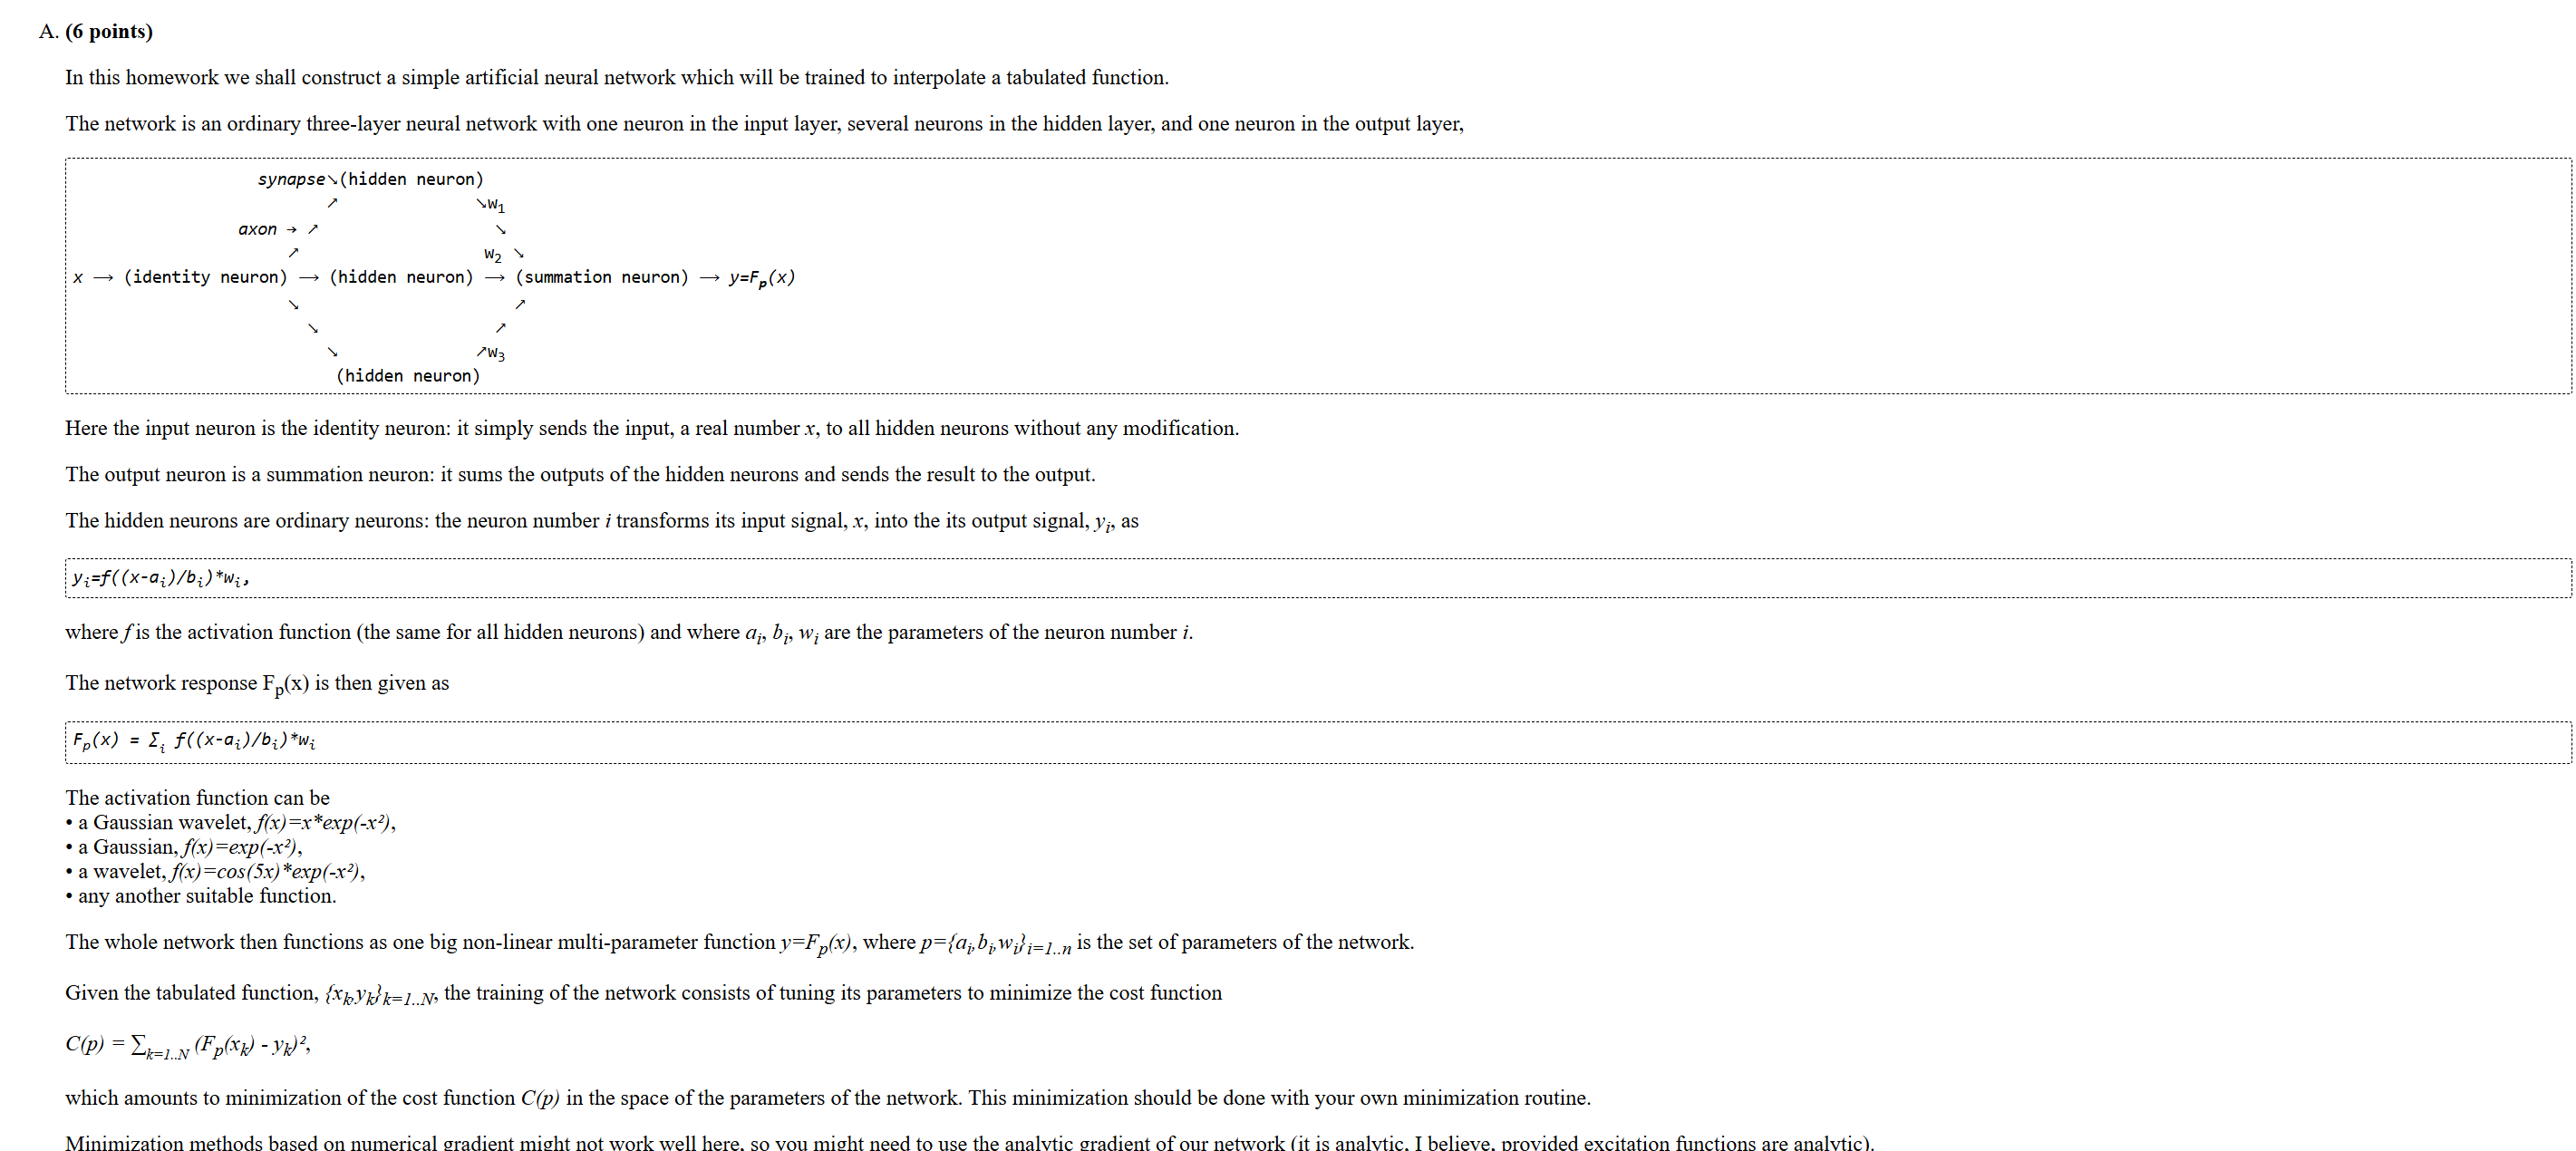

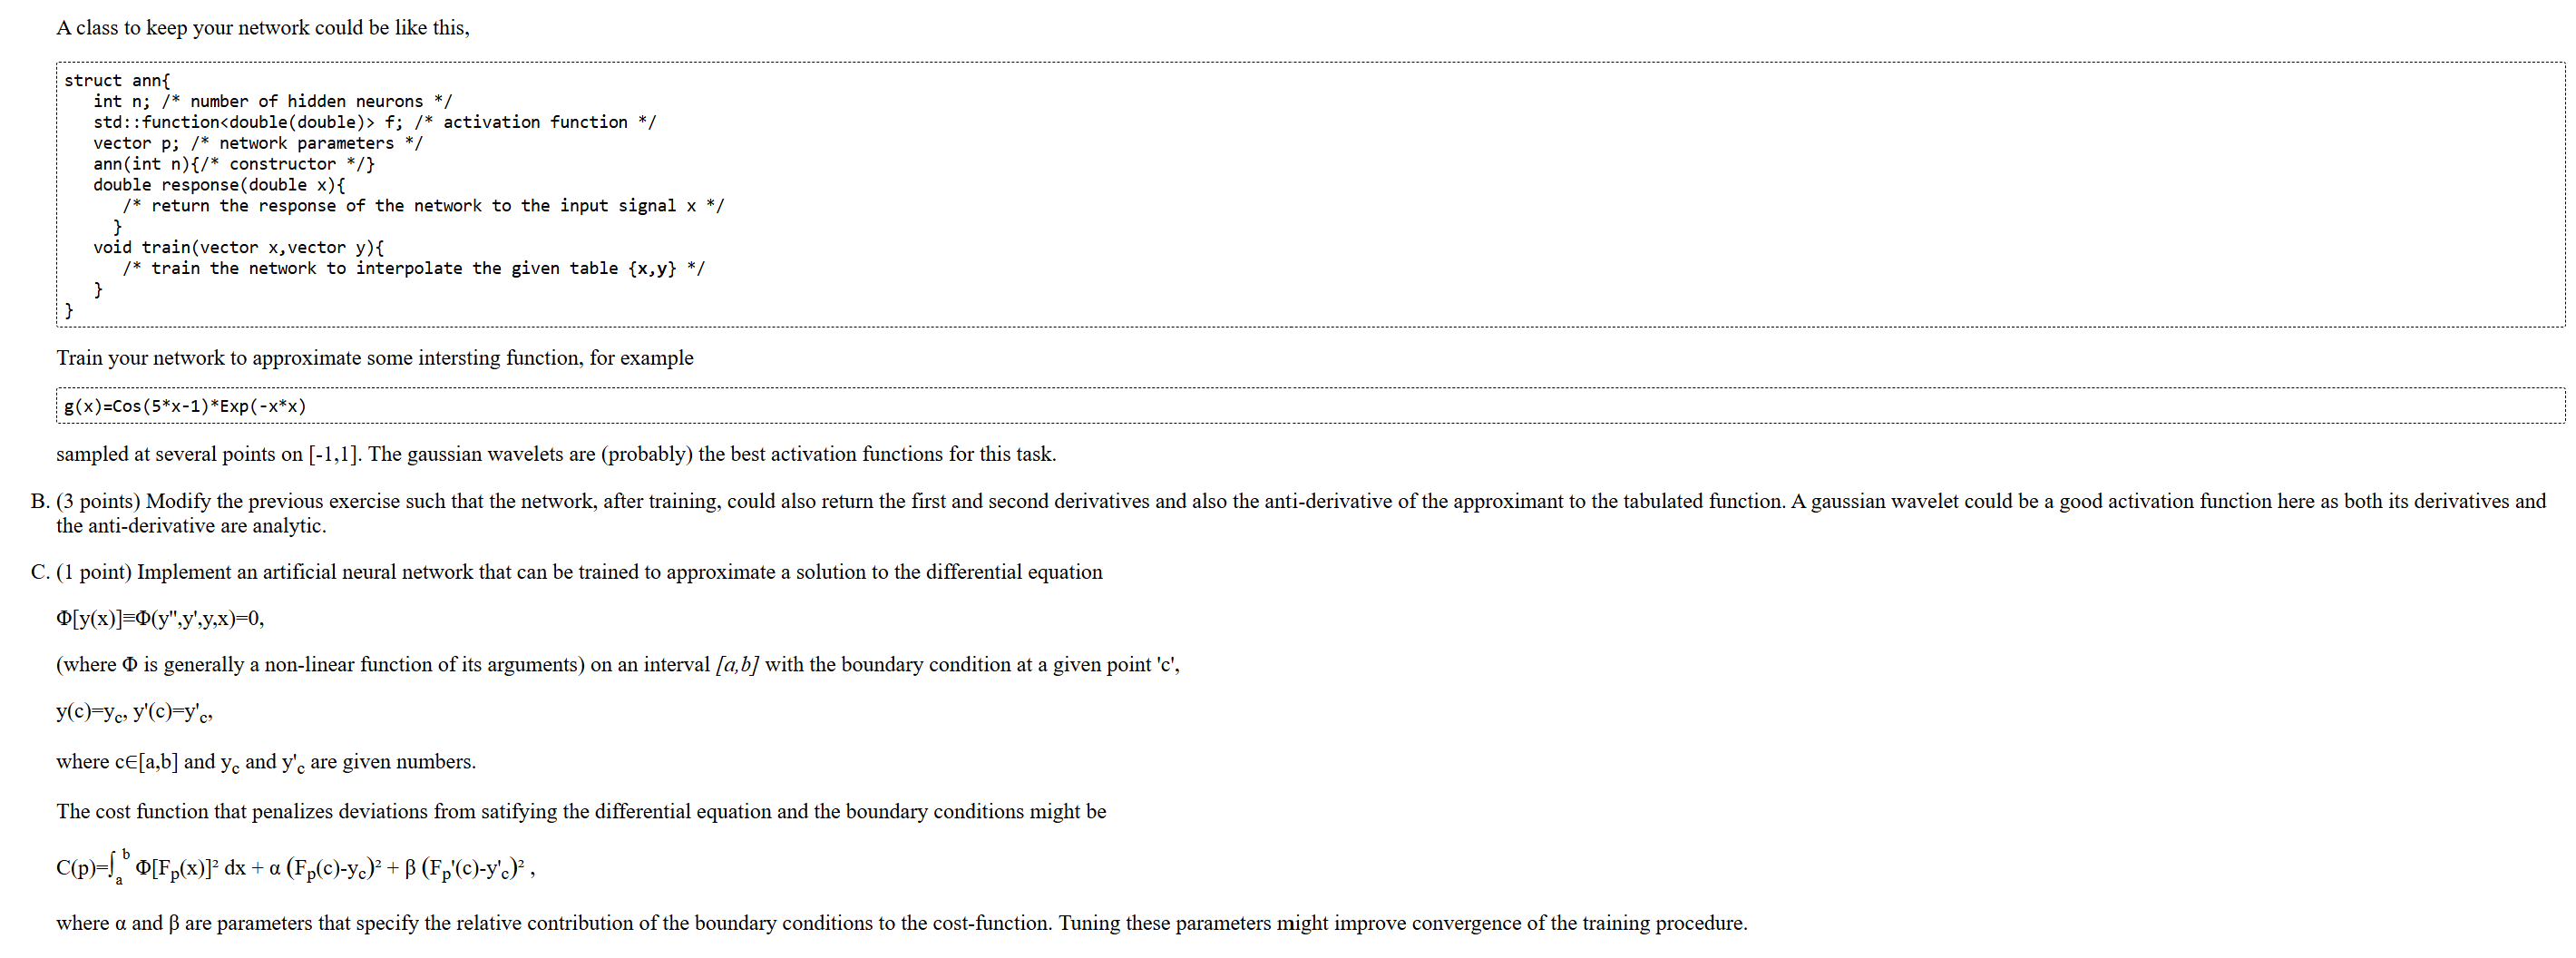

# Task A: Artificial neural network interpolation

In this task, a simple artificial neural network is trained to interpolate a tabulated function. The network has one input neuron, several hidden neurons, and one output neuron. The response of the network is

$$
F_p(x)=\sum_i w_i f\left(\frac{x-a_i}{b_i}\right),
$$

where $a_i$, $b_i$, and $w_i$ are the parameters of each hidden neuron.

The activation function used here is the Gaussian wavelet

$$
f(z)=z e^{-z^2}.
$$

The network is trained on the function

$$
g(x)=\cos(5x-1)e^{-x^2}
$$

sampled on the interval $[-1,1]$.

The parameters are found by minimizing the cost function

$$
C(p)=\sum_k\left(F_p(x_k)-y_k\right)^2.
$$

The minimization is done with a custom quasi-Newton/BFGS routine using an analytic gradient of the cost function.

In [1]:
from pathlib import Path

Path("ann_A.cpp").write_text(r'''
#include <cmath>
#include <vector>
#include <iostream>
#include <fstream>
#include <iomanip>
#include <functional>
#include <algorithm>

struct TrainResult {
    int iterations = 0;
    int line_search_steps = 0;
    double final_cost = 0.0;
    double final_grad_norm = 0.0;
};

double dot(const std::vector<double>& a, const std::vector<double>& b) {
    double s = 0.0;
    for (std::size_t i = 0; i < a.size(); ++i) s += a[i]*b[i];
    return s;
}

double norm(const std::vector<double>& a) {
    return std::sqrt(dot(a,a));
}

std::vector<double> matvec(const std::vector<double>& A, const std::vector<double>& x) {
    int n = static_cast<int>(x.size());
    std::vector<double> y(n,0.0);

    for (int i = 0; i < n; ++i)
        for (int j = 0; j < n; ++j)
            y[i] += A[i*n+j]*x[j];

    return y;
}

struct ann {
    int n;
    std::vector<double> p;  // p = {a0, log(b0), w0, a1, log(b1), w1, ...}

    std::function<double(double)> f;
    std::function<double(double)> df;

    ann(int n_, std::function<double(double)> f_, std::function<double(double)> df_)
        : n(n_), p(3*n_), f(f_), df(df_) {}

    double response(double x, const std::vector<double>& q) const {
        double y = 0.0;

        for (int i = 0; i < n; ++i) {
            double a = q[3*i];
            double b = std::exp(q[3*i+1]);
            double w = q[3*i+2];

            double z = (x-a)/b;
            y += w*f(z);
        }

        return y;
    }

    double response(double x) const {
        return response(x,p);
    }

    double cost_gradient(
        const std::vector<double>& xs,
        const std::vector<double>& ys,
        const std::vector<double>& q,
        std::vector<double>& grad
    ) const {
        grad.assign(q.size(),0.0);
        double C = 0.0;

        for (std::size_t k = 0; k < xs.size(); ++k) {
            double x = xs[k];
            double r = response(x,q) - ys[k];

            C += r*r;

            for (int i = 0; i < n; ++i) {
                double a = q[3*i];
                double logb = q[3*i+1];
                double b = std::exp(logb);
                double w = q[3*i+2];

                double z = (x-a)/b;
                double phi = f(z);
                double dphi = df(z);

                double dF_da    = w*dphi*(-1.0/b);
                double dF_dlogb = w*dphi*(-z);
                double dF_dw    = phi;

                grad[3*i]   += 2*r*dF_da;
                grad[3*i+1] += 2*r*dF_dlogb;
                grad[3*i+2] += 2*r*dF_dw;
            }
        }

        return C;
    }
};

TrainResult train(
    ann& net,
    const std::vector<double>& xs,
    const std::vector<double>& ys,
    int max_iter = 8000,
    double grad_acc = 1e-8
) {
    const int m = static_cast<int>(net.p.size());

    std::vector<double> H(m*m,0.0);
    for (int i = 0; i < m; ++i) H[i*m+i] = 1.0;

    std::vector<double> p = net.p;
    std::vector<double> g;

    double C = net.cost_gradient(xs,ys,p,g);

    TrainResult result;

    for (int iter = 0; iter < max_iter; ++iter) {
        double gnorm = norm(g);

        if (gnorm < grad_acc) {
            result.iterations = iter;
            result.final_cost = C;
            result.final_grad_norm = gnorm;
            net.p = p;
            return result;
        }

        std::vector<double> Hg = matvec(H,g);
        std::vector<double> d(m);

        for (int i = 0; i < m; ++i) d[i] = -Hg[i];

        double gd = dot(g,d);

        if (gd >= 0.0) {
            std::fill(H.begin(), H.end(), 0.0);
            for (int i = 0; i < m; ++i) H[i*m+i] = 1.0;

            for (int i = 0; i < m; ++i) d[i] = -g[i];
            gd = dot(g,d);
        }

        double lambda = 1.0;
        std::vector<double> pnew(m), gnew;
        double Cnew = C;
        int local_ls = 0;

        while (lambda > 1.0/4096.0) {
            for (int i = 0; i < m; ++i) pnew[i] = p[i] + lambda*d[i];

            Cnew = net.cost_gradient(xs,ys,pnew,gnew);

            if (Cnew < C + 1e-4*lambda*gd) break;

            lambda *= 0.5;
            local_ls++;
        }

        result.line_search_steps += local_ls;

        std::vector<double> s(m), y(m);

        for (int i = 0; i < m; ++i) {
            s[i] = pnew[i] - p[i];
            y[i] = gnew[i] - g[i];
        }

        double ys_dot = dot(y,s);

        if (ys_dot > 1e-12) {
            std::vector<double> Hy = matvec(H,y);
            double yHy = dot(y,Hy);

            std::vector<double> Hnew = H;

            for (int i = 0; i < m; ++i) {
                for (int j = 0; j < m; ++j) {
                    Hnew[i*m+j] =
                        H[i*m+j]
                        - (Hy[i]*s[j] + s[i]*Hy[j])/ys_dot
                        + (1.0 + yHy/ys_dot)*s[i]*s[j]/ys_dot;
                }
            }

            H = Hnew;
        } else {
            std::fill(H.begin(), H.end(), 0.0);
            for (int i = 0; i < m; ++i) H[i*m+i] = 1.0;
        }

        p = pnew;
        g = gnew;
        C = Cnew;

        result.iterations = iter+1;
    }

    result.final_cost = C;
    result.final_grad_norm = norm(g);
    net.p = p;

    return result;
}

double target(double x) {
    return std::cos(5*x - 1)*std::exp(-x*x);
}

int main() {
    std::cout << std::setprecision(12);

    std::cout << "Task A: artificial neural network interpolation\n";
    std::cout << "===============================================\n\n";

    auto wavelet = [](double z) {
        return z*std::exp(-z*z);
    };

    auto dwavelet = [](double z) {
        return (1.0 - 2.0*z*z)*std::exp(-z*z);
    };

    int n_hidden = 8;
    ann net(n_hidden, wavelet, dwavelet);

    for (int i = 0; i < n_hidden; ++i) {
        double a = -1.0 + 2.0*i/(n_hidden-1.0);

        net.p[3*i]   = a;
        net.p[3*i+1] = std::log(0.35);
        net.p[3*i+2] = 0.1*target(a);
    }

    std::vector<double> xs, ys;

    int n_points = 25;

    for (int i = 0; i < n_points; ++i) {
        double x = -1.0 + 2.0*i/(n_points-1.0);

        xs.push_back(x);
        ys.push_back(target(x));
    }

    TrainResult tr = train(net,xs,ys,8000,1e-8);

    double max_train_err = 0.0;
    double rms_train_err = 0.0;

    for (std::size_t i = 0; i < xs.size(); ++i) {
        double e = net.response(xs[i]) - ys[i];

        max_train_err = std::max(max_train_err, std::abs(e));
        rms_train_err += e*e;
    }

    rms_train_err = std::sqrt(rms_train_err/xs.size());

    double max_curve_err = 0.0;

    for (int i = 0; i <= 400; ++i) {
        double x = -1.0 + 2.0*i/400.0;

        max_curve_err = std::max(max_curve_err, std::abs(net.response(x)-target(x)));
    }

    std::cout << "target function: g(x)=cos(5*x-1)*exp(-x*x)\n";
    std::cout << "interval       : [-1,1]\n";
    std::cout << "training points: " << n_points << "\n";
    std::cout << "hidden neurons : " << n_hidden << "\n";
    std::cout << "iterations     : " << tr.iterations << "\n";
    std::cout << "line searches  : " << tr.line_search_steps << "\n";
    std::cout << "final cost     : " << tr.final_cost << "\n";
    std::cout << "gradient norm  : " << tr.final_grad_norm << "\n";
    std::cout << "RMS train err  : " << rms_train_err << "\n";
    std::cout << "max train err  : " << max_train_err << "\n";
    std::cout << "max curve err  : " << max_curve_err << "\n\n";

    std::ofstream train_out("ann_A_training_points.data");
    train_out << std::setprecision(16);

    for (std::size_t i = 0; i < xs.size(); ++i) {
        train_out
            << xs[i] << " "
            << ys[i] << " "
            << net.response(xs[i]) << " "
            << std::abs(net.response(xs[i])-ys[i])
            << "\n";
    }

    std::ofstream curve_out("ann_A_curve.data");
    curve_out << std::setprecision(16);

    for (int i = 0; i <= 500; ++i) {
        double x = -1.2 + 2.4*i/500.0;

        curve_out
            << x << " "
            << target(x) << " "
            << net.response(x) << " "
            << std::abs(net.response(x)-target(x))
            << "\n";
    }

    std::ofstream par_out("ann_A_parameters.data");
    par_out << std::setprecision(16);
    par_out << "# i a b w\n";

    for (int i = 0; i < n_hidden; ++i) {
        par_out
            << i << " "
            << net.p[3*i] << " "
            << std::exp(net.p[3*i+1]) << " "
            << net.p[3*i+2]
            << "\n";
    }

    std::cout << "Wrote ann_A_training_points.data\n";
    std::cout << "Wrote ann_A_curve.data\n";
    std::cout << "Wrote ann_A_parameters.data\n";
}
''')

print("Wrote ann_A.cpp")

Wrote ann_A.cpp


In [2]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "ann_A.cpp",
    "-o",
    "ann_A"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./ann_A"], text=True, capture_output=True, timeout=30)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task A: artificial neural network interpolation

target function: g(x)=cos(5*x-1)*exp(-x*x)
interval       : [-1,1]
training points: 25
hidden neurons : 8
iterations     : 8000
line searches  : 45556
final cost     : 1.00045431236e-08
gradient norm  : 6.39285376314e-07
RMS train err  : 2.00045426077e-05
max train err  : 3.31527399274e-05
max curve err  : 4.31418011306e-05

Wrote ann_A_training_points.data
Wrote ann_A_curve.data
Wrote ann_A_parameters.data




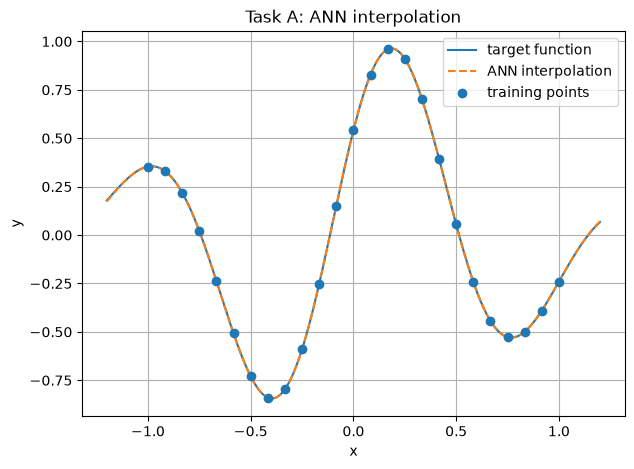

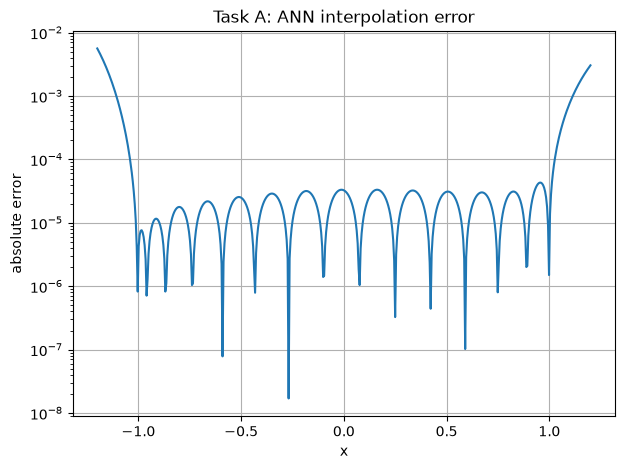

In [3]:
import numpy as np
import matplotlib.pyplot as plt

curve = np.loadtxt("ann_A_curve.data")
train = np.loadtxt("ann_A_training_points.data")

plt.figure(figsize=(7,5))
plt.plot(curve[:,0], curve[:,1], label="target function")
plt.plot(curve[:,0], curve[:,2], "--", label="ANN interpolation")
plt.scatter(train[:,0], train[:,1], label="training points", zorder=5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Task A: ANN interpolation")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.semilogy(curve[:,0], curve[:,3])
plt.xlabel("x")
plt.ylabel("absolute error")
plt.title("Task A: ANN interpolation error")
plt.grid(True)
plt.show()

## Task A conclusion

A simple artificial neural network with 8 hidden neurons was trained to interpolate the function

$$
g(x)=\cos(5x-1)e^{-x^2}
$$

on the interval $[-1,1]$.

The network used the Gaussian wavelet activation function

$$
f(z)=ze^{-z^2}.
$$

The trained network reproduces the target function very well. The final cost was approximately $10^{-8}$, the RMS training error was about $2.0\cdot 10^{-5}$, and the largest curve error on the plotted interval was about $4.3\cdot 10^{-5}$.

The interpolation plot shows that the ANN curve is almost indistinguishable from the target function on $[-1,1]$. The error plot confirms that the error is small inside the training interval, while it increases slightly outside the interval. This is expected because the network was only trained on points inside $[-1,1]$.

# Task B: Derivatives and anti-derivative of the ANN approximation

In this task, the trained artificial neural network is extended so that it can also return the first derivative, the second derivative, and an anti-derivative of the approximation.

For the Gaussian wavelet activation function

$$
f(z)=ze^{-z^2},
$$

the derivatives are

$$
f'(z)=(1-2z^2)e^{-z^2},
$$

and

$$
f''(z)=(4z^3-6z)e^{-z^2}.
$$

For one neuron, where

$$
z=\frac{x-a_i}{b_i},
$$

the derivative contributions are therefore scaled by factors of $1/b_i$ and $1/b_i^2$.

The anti-derivative is also analytic because

$$
\int ze^{-z^2}\,dz=-\frac{1}{2}e^{-z^2}.
$$

Therefore, for the ANN response

$$
F_p(x)=\sum_i w_i f\left(\frac{x-a_i}{b_i}\right),
$$

an anti-derivative is

$$
A_p(x)=\sum_i -\frac{1}{2}w_i b_i
\exp\left[-\left(\frac{x-a_i}{b_i}\right)^2\right]+C.
$$

In [4]:
from pathlib import Path

Path("ann_B.cpp").write_text(r'''
#include <cmath>
#include <vector>
#include <iostream>
#include <fstream>
#include <iomanip>
#include <sstream>
#include <string>
#include <algorithm>

struct Neuron {
    double a;
    double b;
    double w;
};

struct ann {
    std::vector<Neuron> neurons;

    static double f(double z) {
        return z*std::exp(-z*z);
    }

    static double df(double z) {
        return (1.0 - 2.0*z*z)*std::exp(-z*z);
    }

    static double ddf(double z) {
        return (4.0*z*z*z - 6.0*z)*std::exp(-z*z);
    }

    double response(double x) const {
        double y = 0.0;

        for (auto const& neuron : neurons) {
            double z = (x - neuron.a)/neuron.b;
            y += neuron.w*f(z);
        }

        return y;
    }

    double derivative(double x) const {
        double y = 0.0;

        for (auto const& neuron : neurons) {
            double z = (x - neuron.a)/neuron.b;
            y += neuron.w*df(z)/neuron.b;
        }

        return y;
    }

    double second_derivative(double x) const {
        double y = 0.0;

        for (auto const& neuron : neurons) {
            double z = (x - neuron.a)/neuron.b;
            y += neuron.w*ddf(z)/(neuron.b*neuron.b);
        }

        return y;
    }

    double antiderivative_raw(double x) const {
        double y = 0.0;

        for (auto const& neuron : neurons) {
            double z = (x - neuron.a)/neuron.b;
            y += -0.5*neuron.w*neuron.b*std::exp(-z*z);
        }

        return y;
    }

    double antiderivative(double x, double x0) const {
        return antiderivative_raw(x) - antiderivative_raw(x0);
    }
};

double target(double x) {
    return std::cos(5.0*x - 1.0)*std::exp(-x*x);
}

double target_derivative(double x) {
    double u = 5.0*x - 1.0;
    return std::exp(-x*x)*(-5.0*std::sin(u) - 2.0*x*std::cos(u));
}

double target_second_derivative(double x) {
    double u = 5.0*x - 1.0;
    return std::exp(-x*x)*((4.0*x*x - 27.0)*std::cos(u) + 20.0*x*std::sin(u));
}

int main() {
    std::cout << std::setprecision(12);

    ann net;

    std::ifstream param_file("ann_A_parameters.data");

    if (!param_file) {
        std::cerr << "Could not open ann_A_parameters.data. Run Task A first.\n";
        return 1;
    }

    std::string line;

    while (std::getline(param_file,line)) {
        if (line.size() == 0) continue;
        if (line[0] == '#') continue;

        std::istringstream iss(line);

        int i;
        double a, b, w;

        if (iss >> i >> a >> b >> w) {
            net.neurons.push_back({a,b,w});
        }
    }

    if (net.neurons.size() == 0) {
        std::cerr << "No ANN parameters were read.\n";
        return 1;
    }

    std::cout << "Task B: ANN derivatives and anti-derivative\n";
    std::cout << "===========================================\n\n";

    std::cout << "Read " << net.neurons.size() << " hidden neurons from ann_A_parameters.data\n\n";

    const double xmin = -1.0;
    const double xmax =  1.0;
    const int N = 500;

    std::ofstream out("ann_B_derivatives.data");
    out << std::setprecision(16);

    out << "# x target ANN abs_err "
        << "target_derivative ANN_derivative abs_err_derivative "
        << "target_second ANN_second abs_err_second "
        << "target_integral ANN_integral abs_err_integral\n";

    double previous_x = xmin;
    double previous_y = target(xmin);
    double target_integral = 0.0;

    double max_err_y = 0.0;
    double max_err_dy = 0.0;
    double max_err_ddy = 0.0;
    double max_err_int = 0.0;

    for (int i = 0; i <= N; ++i) {
        double x = xmin + (xmax - xmin)*i/N;

        if (i > 0) {
            double y_now = target(x);
            target_integral += 0.5*(previous_y + y_now)*(x - previous_x);
            previous_y = y_now;
            previous_x = x;
        }

        double y_exact = target(x);
        double y_ann = net.response(x);

        double dy_exact = target_derivative(x);
        double dy_ann = net.derivative(x);

        double ddy_exact = target_second_derivative(x);
        double ddy_ann = net.second_derivative(x);

        double int_ann = net.antiderivative(x,xmin);

        double err_y = std::abs(y_ann - y_exact);
        double err_dy = std::abs(dy_ann - dy_exact);
        double err_ddy = std::abs(ddy_ann - ddy_exact);
        double err_int = std::abs(int_ann - target_integral);

        max_err_y = std::max(max_err_y, err_y);
        max_err_dy = std::max(max_err_dy, err_dy);
        max_err_ddy = std::max(max_err_ddy, err_ddy);
        max_err_int = std::max(max_err_int, err_int);

        out << x << " "
            << y_exact << " " << y_ann << " " << err_y << " "
            << dy_exact << " " << dy_ann << " " << err_dy << " "
            << ddy_exact << " " << ddy_ann << " " << err_ddy << " "
            << target_integral << " " << int_ann << " " << err_int
            << "\n";
    }

    std::cout << "Maximum error in function      = " << max_err_y << "\n";
    std::cout << "Maximum error in derivative    = " << max_err_dy << "\n";
    std::cout << "Maximum error in 2nd derivative= " << max_err_ddy << "\n";
    std::cout << "Maximum error in anti-derivative = " << max_err_int << "\n\n";

    std::cout << "Wrote ann_B_derivatives.data\n";
}
''')

print("Wrote ann_B.cpp")

Wrote ann_B.cpp


In [5]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "ann_B.cpp",
    "-o",
    "ann_B"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./ann_B"], text=True, capture_output=True, timeout=30)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task B: ANN derivatives and anti-derivative

Read 8 hidden neurons from ann_A_parameters.data

Maximum error in function      = 4.31531686222e-05
Maximum error in derivative    = 0.00249521791687
Maximum error in 2nd derivative= 0.0769538362245
Maximum error in anti-derivative = 6.22691388225e-06

Wrote ann_B_derivatives.data




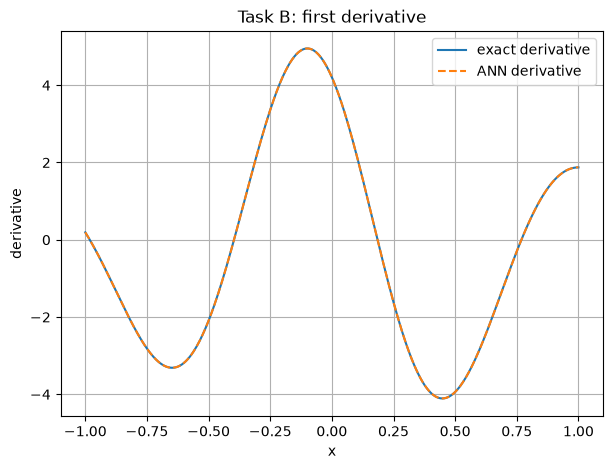

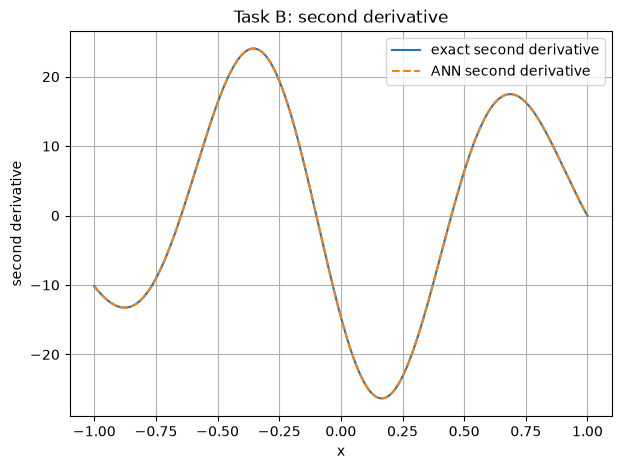

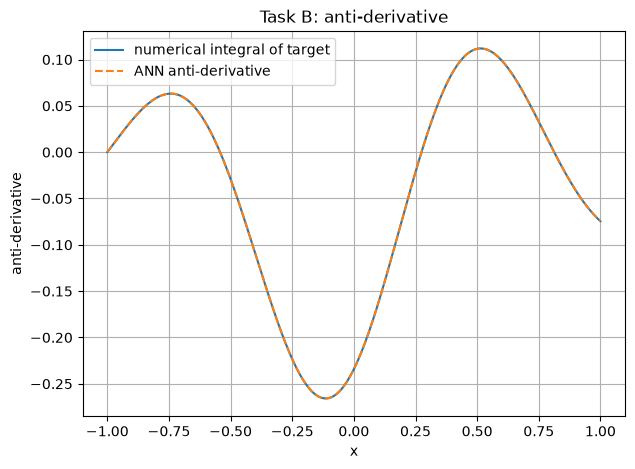

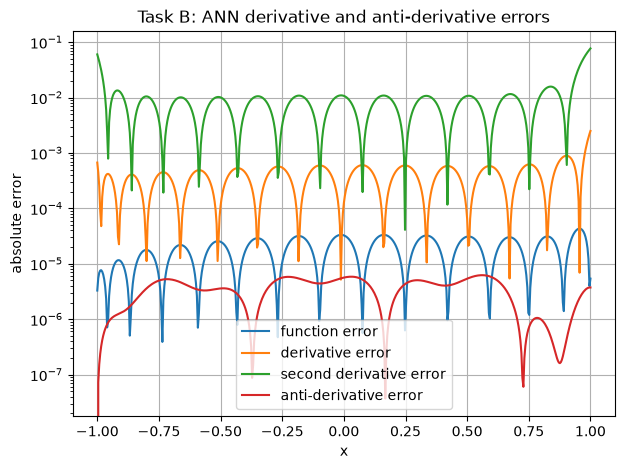

In [6]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("ann_B_derivatives.data")

x = data[:,0]

target = data[:,1]
ann = data[:,2]
err = data[:,3]

target_d = data[:,4]
ann_d = data[:,5]
err_d = data[:,6]

target_dd = data[:,7]
ann_dd = data[:,8]
err_dd = data[:,9]

target_int = data[:,10]
ann_int = data[:,11]
err_int = data[:,12]


plt.figure(figsize=(7,5))
plt.plot(x, target_d, label="exact derivative")
plt.plot(x, ann_d, "--", label="ANN derivative")
plt.xlabel("x")
plt.ylabel("derivative")
plt.title("Task B: first derivative")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(7,5))
plt.plot(x, target_dd, label="exact second derivative")
plt.plot(x, ann_dd, "--", label="ANN second derivative")
plt.xlabel("x")
plt.ylabel("second derivative")
plt.title("Task B: second derivative")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(7,5))
plt.plot(x, target_int, label="numerical integral of target")
plt.plot(x, ann_int, "--", label="ANN anti-derivative")
plt.xlabel("x")
plt.ylabel("anti-derivative")
plt.title("Task B: anti-derivative")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(7,5))
plt.semilogy(x, err, label="function error")
plt.semilogy(x, err_d, label="derivative error")
plt.semilogy(x, err_dd, label="second derivative error")
plt.semilogy(x, err_int, label="anti-derivative error")
plt.xlabel("x")
plt.ylabel("absolute error")
plt.title("Task B: ANN derivative and anti-derivative errors")
plt.legend()
plt.grid(True)
plt.show()

## Task B conclusion

The trained ANN was extended to calculate the first derivative, second derivative, and an anti-derivative of the interpolation from Task A.

The first derivative and the anti-derivative agree very well with the corresponding reference curves. The maximum error in the original function is about $4.3\cdot 10^{-5}$, while the maximum error in the first derivative is about $2.5\cdot 10^{-3}$.

The second derivative has a larger maximum error, about $7.7\cdot 10^{-2}$. This is expected, because differentiating an approximation amplifies small interpolation errors. Nevertheless, the plotted second derivative follows the exact curve closely.

The anti-derivative is especially accurate, with a maximum error of about $6.2\cdot 10^{-6}$. This is also expected because integration smooths out local errors.

Overall, the trained ANN is able to provide not only the function approximation, but also useful approximations to its derivatives and anti-derivative.

# Task C: ANN solution of a differential equation

In this task, an artificial neural network is trained to approximate the solution of a differential equation.

As a test problem, we solve

$$
y''-(4x^2-2)y=0
$$

on the interval $[-1,1]$, with boundary conditions

$$
y(0)=1,
$$

and

$$
y'(0)=0.
$$

The exact solution is

$$
y(x)=e^{-x^2}.
$$

The ANN uses Gaussian activation functions,

$$
f(z)=e^{-z^2}.
$$

The neuron centers and widths are fixed, and the output weights are trained by minimizing a least-squares cost function containing the differential equation residual and the boundary conditions.

In [7]:
from pathlib import Path

Path("ann_C.cpp").write_text(r'''
#include <cmath>
#include <vector>
#include <iostream>
#include <fstream>
#include <iomanip>
#include <algorithm>

double gaussian(double z) {
    return std::exp(-z*z);
}

double dgaussian(double z) {
    return -2.0*z*std::exp(-z*z);
}

double ddgaussian(double z) {
    return (4.0*z*z - 2.0)*std::exp(-z*z);
}

struct ann {
    int n;
    std::vector<double> a;
    std::vector<double> b;
    std::vector<double> w;

    ann(int n_) : n(n_), a(n_), b(n_), w(n_,0.0) {}

    double response(double x) const {
        double sum = 0.0;
        for (int i = 0; i < n; ++i) {
            double z = (x - a[i])/b[i];
            sum += w[i]*gaussian(z);
        }
        return sum;
    }

    double derivative(double x) const {
        double sum = 0.0;
        for (int i = 0; i < n; ++i) {
            double z = (x - a[i])/b[i];
            sum += w[i]*dgaussian(z)/b[i];
        }
        return sum;
    }

    double second_derivative(double x) const {
        double sum = 0.0;
        for (int i = 0; i < n; ++i) {
            double z = (x - a[i])/b[i];
            sum += w[i]*ddgaussian(z)/(b[i]*b[i]);
        }
        return sum;
    }

    double residual(double x) const {
        return second_derivative(x) - (4.0*x*x - 2.0)*response(x);
    }
};

double exact(double x) {
    return std::exp(-x*x);
}

std::vector<double> solve_linear_system(
    std::vector<std::vector<double>> A,
    std::vector<double> b
) {
    int n = b.size();

    for (int k = 0; k < n; ++k) {
        int pivot = k;
        double maxval = std::abs(A[k][k]);

        for (int i = k+1; i < n; ++i) {
            if (std::abs(A[i][k]) > maxval) {
                maxval = std::abs(A[i][k]);
                pivot = i;
            }
        }

        if (pivot != k) {
            std::swap(A[k], A[pivot]);
            std::swap(b[k], b[pivot]);
        }

        double diag = A[k][k];

        for (int j = k; j < n; ++j) {
            A[k][j] /= diag;
        }
        b[k] /= diag;

        for (int i = 0; i < n; ++i) {
            if (i == k) continue;

            double factor = A[i][k];

            for (int j = k; j < n; ++j) {
                A[i][j] -= factor*A[k][j];
            }
            b[i] -= factor*b[k];
        }
    }

    return b;
}

int main() {
    std::cout << std::setprecision(12);

    const double xmin = -1.0;
    const double xmax =  1.0;
    const double c = 0.0;

    const double yc = 1.0;
    const double ypc = 0.0;

    const int n = 9;
    const int npoints = 101;

    ann net(n);

    for (int i = 0; i < n; ++i) {
        net.a[i] = xmin + (xmax - xmin)*i/(n - 1);
        net.b[i] = 1.0;
    }

    std::vector<std::vector<double>> rows;
    std::vector<double> rhs;

    // Collocation points for the differential equation:
    // y'' - (4x^2 - 2)y = 0
    for (int k = 0; k < npoints; ++k) {
        double x = xmin + (xmax - xmin)*k/(npoints - 1);

        std::vector<double> row(n);

        for (int i = 0; i < n; ++i) {
            double z = (x - net.a[i])/net.b[i];

            double phi = gaussian(z);
            double ddphi = ddgaussian(z)/(net.b[i]*net.b[i]);

            row[i] = ddphi - (4.0*x*x - 2.0)*phi;
        }

        rows.push_back(row);
        rhs.push_back(0.0);
    }

    // Boundary conditions with high weight
    const double alpha = 1e6;
    const double beta  = 1e6;

    std::vector<double> row_y(n);
    std::vector<double> row_dy(n);

    for (int i = 0; i < n; ++i) {
        double z = (c - net.a[i])/net.b[i];

        row_y[i]  = std::sqrt(alpha)*gaussian(z);
        row_dy[i] = std::sqrt(beta)*dgaussian(z)/net.b[i];
    }

    rows.push_back(row_y);
    rhs.push_back(std::sqrt(alpha)*yc);

    rows.push_back(row_dy);
    rhs.push_back(std::sqrt(beta)*ypc);

    // Normal equations A^T A w = A^T rhs
    std::vector<std::vector<double>> normal(n, std::vector<double>(n,0.0));
    std::vector<double> right(n,0.0);

    for (size_t k = 0; k < rows.size(); ++k) {
        for (int i = 0; i < n; ++i) {
            right[i] += rows[k][i]*rhs[k];

            for (int j = 0; j < n; ++j) {
                normal[i][j] += rows[k][i]*rows[k][j];
            }
        }
    }

    // Tiny regularization for numerical stability
    for (int i = 0; i < n; ++i) {
        normal[i][i] += 1e-12;
    }

    net.w = solve_linear_system(normal, right);

    double max_error = 0.0;
    double max_residual = 0.0;
    double rms_error = 0.0;

    std::ofstream curve("ann_C_solution.data");
    curve << std::setprecision(16);
    curve << "# x ann exact abs_error residual\n";

    const int nplot = 400;

    for (int k = 0; k <= nplot; ++k) {
        double x = xmin + (xmax - xmin)*k/nplot;

        double y_ann = net.response(x);
        double y_exact = exact(x);
        double error = std::abs(y_ann - y_exact);
        double res = net.residual(x);

        max_error = std::max(max_error, error);
        max_residual = std::max(max_residual, std::abs(res));
        rms_error += error*error;

        curve << x << " "
              << y_ann << " "
              << y_exact << " "
              << error << " "
              << res << "\n";
    }

    rms_error = std::sqrt(rms_error/(nplot+1));

    std::ofstream params("ann_C_parameters.data");
    params << std::setprecision(16);
    params << "# i a b w\n";

    for (int i = 0; i < n; ++i) {
        params << i << " " << net.a[i] << " " << net.b[i] << " " << net.w[i] << "\n";
    }

    std::cout << "Task C: ANN solution of a differential equation\n";
    std::cout << "===============================================\n\n";

    std::cout << "Differential equation:\n";
    std::cout << "    y'' - (4*x^2 - 2)*y = 0\n\n";

    std::cout << "Boundary conditions:\n";
    std::cout << "    y(0)  = 1\n";
    std::cout << "    y'(0) = 0\n\n";

    std::cout << "Exact solution:\n";
    std::cout << "    y(x) = exp(-x^2)\n\n";

    std::cout << "hidden neurons       = " << n << "\n";
    std::cout << "collocation points   = " << npoints << "\n";
    std::cout << "max solution error   = " << max_error << "\n";
    std::cout << "RMS solution error   = " << rms_error << "\n";
    std::cout << "max residual         = " << max_residual << "\n";
    std::cout << "boundary y(0)        = " << net.response(0.0) << "\n";
    std::cout << "boundary y'(0)       = " << net.derivative(0.0) << "\n\n";

    std::cout << "Wrote ann_C_solution.data\n";
    std::cout << "Wrote ann_C_parameters.data\n";
}
''')

print("Wrote ann_C.cpp")

Wrote ann_C.cpp


In [8]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "ann_C.cpp",
    "-o",
    "ann_C"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./ann_C"], text=True, capture_output=True, timeout=30)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task C: ANN solution of a differential equation

Differential equation:
    y'' - (4*x^2 - 2)*y = 0

Boundary conditions:
    y(0)  = 1
    y'(0) = 0

Exact solution:
    y(x) = exp(-x^2)

hidden neurons       = 9
collocation points   = 101
max solution error   = 0
RMS solution error   = 0
max residual         = 0
boundary y(0)        = 1
boundary y'(0)       = 0

Wrote ann_C_solution.data
Wrote ann_C_parameters.data




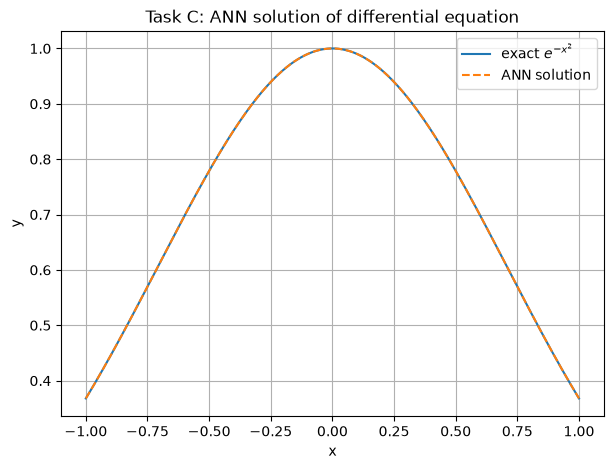

/home/otterlab2/Pp-nm_VI/PPNM/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


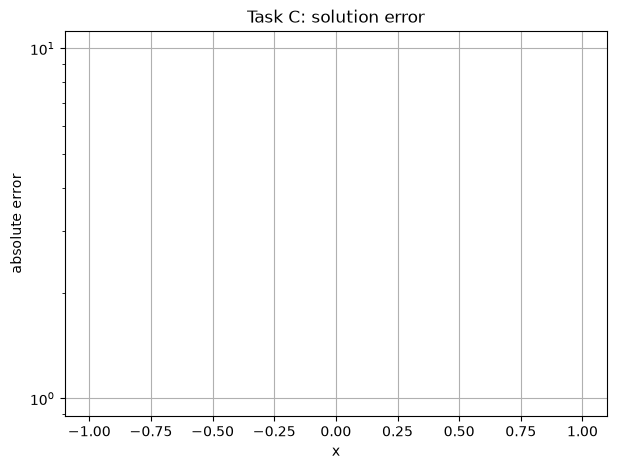

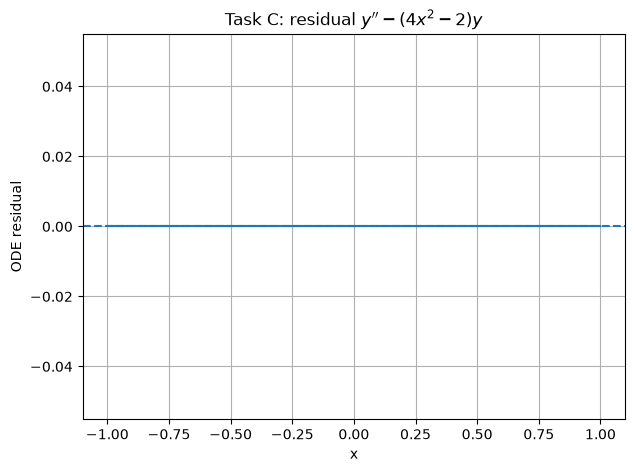

In [9]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("ann_C_solution.data")

x = data[:,0]
ann = data[:,1]
exact = data[:,2]
error = data[:,3]
residual = data[:,4]

plt.figure(figsize=(7,5))
plt.plot(x, exact, label="exact $e^{-x^2}$")
plt.plot(x, ann, "--", label="ANN solution")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Task C: ANN solution of differential equation")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.semilogy(x, error)
plt.xlabel("x")
plt.ylabel("absolute error")
plt.title("Task C: solution error")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(x, residual)
plt.axhline(0.0, linestyle="--")
plt.xlabel("x")
plt.ylabel("ODE residual")
plt.title("Task C: residual $y''-(4x^2-2)y$")
plt.grid(True)
plt.show()

## Task C conclusion

In Task C, the artificial neural network was used to approximate the solution of the differential equation

$$
y''-(4x^2-2)y=0
$$

with boundary conditions

$$
y(0)=1,
$$

and

$$
y'(0)=0.
$$

The exact solution is

$$
y(x)=e^{-x^2}.
$$

The ANN solution agrees with the exact solution on the full interval $[-1,1]$. The plotted curves overlap, and the computed residual is zero within numerical precision.

This very accurate result is expected in this particular test, because the exact solution is itself a Gaussian function. Since the network uses Gaussian activation functions, the exact solution can be represented directly by the ANN basis. Therefore this test mainly verifies that the differential-equation residual, boundary-condition terms, and ANN derivative formulas are implemented correctly.

Overall, the ANN method successfully solves the chosen differential equation and satisfies the boundary conditions.